# Pandora Visibility — Example Usage

This notebook walks through the core features of the `pandoravisibility` package, which calculates when astronomical targets are observable from the [Pandora SmallSat](https://pandoramission.github.io/pandora-mission/).

**What you need to run this notebook:**
- A Two-Line Element (TLE) set describing Pandora's orbit. TLEs are the standard way to represent a satellite's orbital elements; SGP4 propagates them to predict the satellite's position at any future time.
- Target coordinates as right ascension (RA) and declination (Dec) in the ICRS frame.
- All angular parameters must be passed as `astropy.units.Quantity` objects (e.g. `30 * u.deg`).

**What the software calculates:**
The `Visibility` class checks whether a target clears all keep-out constraints at each time step:

| Constraint | Parameter | Default |
|---|---|---|
| Sun avoidance | `sun_min` | 91° |
| Moon avoidance | `moon_min` | 25° |
| Earth limb (uniform) | `earthlimb_min` | 20° |
| Earth limb (day) | `earthlimb_day_min` | *None* (uses `earthlimb_min`) |
| Earth limb (night) | `earthlimb_night_min` | *None* (uses `earthlimb_min`) |
| Mars avoidance | `mars_min` | 0° (disabled) |
| Jupiter avoidance | `jupiter_min` | 0° (disabled) |
| Star tracker Sun | `st_sun_min` | 0° (disabled) |
| Star tracker Moon | `st_moon_min` | 0° (disabled) |
| Star tracker Earth limb | `st_earthlimb_min` | 0° (disabled) |
| Required star trackers | `st_required` | 1 |

**Outline:**
1. Setup and TLE
2. Creating a `Visibility` instance with default constraints
3. Day/night Earth limb constraints
4. Star tracker constraints
5. Full-year simulation and per-constraint inspection
6. Custom constraints
7. Daily duty-cycle averages
8. Yearly visibility analysis (convenience function)
9. Multi-target comparison

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time, TimeDelta
from astropy.visualization import time_support

from pandoravisibility import Visibility, analyze_yearly_visibility, plot_yearly_visibility

In [2]:
# Draft TLE for Pandora — use the most up-to-date one for real work!
line1 = "1 67395U 80229J   26057.99991898  .00000000  00000-0  37770-3 0    03"
line2 = "2 67395  97.8009  58.3973 0006599 121.8878 132.9207 14.87804761    04"


## 2. Create a default Visibility instance

The simplest way to get started is to create a `Visibility` object with just the two TLE lines.
This uses all the default keep-out angles. As of v1.3.0 those are Pandora's flight values: Sun ≥ 91°, Moon ≥ 20°, the dynamic DPC Earth limb wedge, and star tracker keep-outs of Sun ≥ 50°, Moon ≥ 20° and Earth limb ≥ 30° with one tracker required.

You can inspect the active constraints with `print(vis)` — it shows a compact representation of every non-zero constraint.

In [3]:
vis = Visibility(line1, line2)
print(vis)
print(f"Orbital period: {vis.get_period():.2f}")

<Visibility: SAT67395 [moon≥20 deg, sun≥91 deg, limb=dynamic, st_sun≥50 deg, st_moon≥20 deg, st_limb≥30 deg, st_req=1]>
Orbital period: 96.79 min


## 3. Day/night Earth limb constraints

The Earth limb constraint can be split into separate **day** and **night** thresholds.
When the nearest limb point is sunlit, `earthlimb_day_min` applies; otherwise `earthlimb_night_min` is used.
This models the fact that stray light from the sunlit Earth is brighter, so a larger keep-out is needed during the day.

If you set only `earthlimb_min`, a single threshold is used regardless of illumination.

In [4]:
# Set different earth limb constraints for day and night
vis_daynight = Visibility(
    line1, line2,
    earthlimb_day_min=15 * u.deg,  # Stricter during daylight
    earthlimb_night_min=5 * u.deg  # Relaxed at night
)

target_coord = SkyCoord(258.831, 4.96068, frame="icrs", unit="deg")
times = Time("2026-01-05T00:00:00.000") + TimeDelta(np.arange(0, 24*60, 10) * u.min)

daynight_vis = vis_daynight.get_visibility(target_coord, times)["visible"]
print("Day/Night earth limb constraint applied:", daynight_vis)

Day/Night earth limb constraint applied: [False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False]


## 4. Star tracker constraints

Pandora has two star trackers at fixed offsets from the boresight. You can require one or both to be clear of the Sun, Moon, and/or Earth limb. Use the following options:

- `st_sun_min`, `st_moon_min`, `st_earthlimb_min` — global keep-out angles applied to both trackers
- `st1_earthlimb_min`, `st2_earthlimb_min` — per-tracker Earth limb overrides
- `st_required` — number of trackers that must pass (1 or 2)

When star tracker constraints are active, `get_visibility()` automatically computes the spacecraft attitude (roll angle about the boresight) to maximize solar panel power, then checks both tracker boresights against the keep-out zones.

`get_visibility()` returns a dict: the boolean verdict is `result["visible"]`, alongside the attitude and per-timestep detail (`boresight_visible`, `roll_deg`, `n_visible`, `n_st_pass`, `solar_power_frac`). Pass a fixed `roll`, or `optimize_roll=True` to sweep for the best single roll over the given timesteps.

In [5]:
# Require both star trackers to be clear of Sun and Earth limb
vis_st = Visibility(
    line1, line2,
    st_sun_min=30 * u.deg,  # Sun keep-out for both trackers
    st_earthlimb_min=10 * u.deg,  # Earth limb keep-out
    st_required=2  # Require both trackers
)

st_vis = vis_st.get_visibility(target_coord, times)["visible"]
print("Star tracker constraint applied:", st_vis)

Star tracker constraint applied: [False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False]


## 5. Full-year simulation

Now we simulate a full year (Jan 2026 – Feb 2027) at 10-minute cadence using the default `Visibility` instance.
This gives us ~57,000 time steps — enough to see seasonal patterns and orbit-by-orbit structure.

**Tip:** The time resolution is a trade-off. Finer cadence (e.g. 1 min) captures every limb crossing but takes longer. For duty-cycle estimates, 10 minutes is usually sufficient.

In [6]:
# Define start and stop times
tstart = Time("2026-01-05T00:00:00.000")
tstop = Time("2027-02-05T00:00:00.000")  # Example stop time

# Calculate times with a step of 10 minute
deltas = np.arange(0, (tstop - tstart).to_value(u.min), 10) * u.min
times = tstart + TimeDelta(deltas)


# Use these times with your Visibility module
state = vis.get_state(times)

In [7]:
# Target: GJ 1214 (RA=258.831°, Dec=+4.961°)
target_coord = SkyCoord(258.831, 4.96068, frame="icrs", unit="deg")
targ_vis = vis.get_visibility(target_coord, times)["visible"]
print(f"GJ 1214 is visible at {targ_vis.sum()} of {len(times)} time steps "
      f"({100 * targ_vis.mean():.1f}% duty cycle)")

GJ 1214 is visible at 9083 of 57024 time steps (15.9% duty cycle)


### Inspecting individual constraints

`get_all_constraints()` returns a dict of boolean arrays — one per constraint body — so you can see **which** constraint is limiting visibility at each time step. You can also call `get_constraint()` for a single body, or `get_separations()` to get the actual angular distances.

In [8]:
# we can get the constraints on any single body like this
# moon_vis = vis.get_constraint(target_coord, "moon", times)
# sun_vis = vis.get_constraint(target_coord, "sun", times)
# earthlimb_vis = vis.get_constraint(target_coord, "earthlimb", times)

# or we can get them all
all_vis = vis.get_all_constraints(target_coord, times)
moon_vis = all_vis["moon"]
sun_vis = all_vis["sun"]
earthlimb_vis = all_vis["earthlimb"]

In [9]:
# Actual angular separations (returned as a dict of Quantity arrays)
# This computes all bodies including Jupiter and Mars even if their constraints are 0
seps = vis.get_separations(target_coord, times)
for body, sep in seps.items():
    print(f"  {body:>12s}: min={sep.min():.1f}, max={sep.max():.1f}")

          moon: min=31.5 deg, max=148.6 deg
           sun: min=27.9 deg, max=152.1 deg
          mars: min=39.4 deg, max=152.1 deg
       jupiter: min=107.8 deg, max=141.5 deg
     earthlimb: min=-65.9 deg, max=113.3 deg


### Human-readable summary

`summary()` prints a formatted report for a **single** time step showing every constraint, whether it passes or fails, the required threshold, and the actual angular separation. This is useful for debugging or quickly checking what is happening at a particular moment.

In [10]:
# we can print a summary for a single time
print(vis.summary(target_coord, times[0]))

Visibility Summary
Target: 17h15m19.4s +04d57m38.4s
Time:   2026-01-05 00:00:00.000
Sat:    67395
Moon       ✓ PASS (req:   20.0 deg, actual:  123.7 deg)
Sun        ✗ FAIL (req:   91.0 deg, actual:   38.0 deg)
Earthlimb  ✗ FAIL (req:   44.0 deg [illum 74.9°], actual:   11.3 deg)
------------------------------------------------------------
Star Tracker Constraints (need ≥1 tracker passing):
  ST1       ✗ FAIL
    sun:✓ req:  50.0 deg act: 124.8 deg
    moon:✓ req:  20.0 deg act:  60.9 deg
    limb:✗ req:  30.0 deg act: -41.9 deg
  ST2       ✗ FAIL
    sun:✓ req:  50.0 deg act: 124.8 deg
    moon:✓ req:  20.0 deg act:  35.5 deg
    limb:✗ req:  30.0 deg act:  26.1 deg
  Result   ✗ FAIL
Overall: ✗ NOT VISIBLE


### Plotting visibility over time

Plotting the boolean visibility arrays against UTC time is the quickest way to see the seasonal structure. The first plot below shows all constraints overlaid for the full year; the second zooms into a 2-day window where you can see individual orbits and the Earth limb occultations.

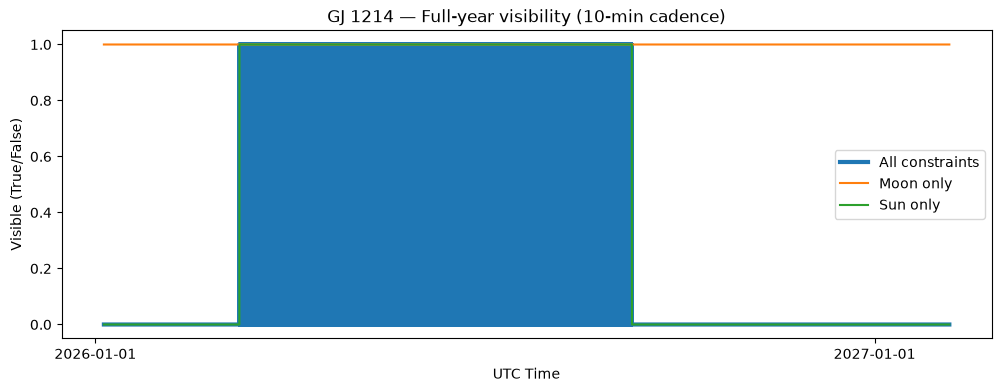

In [11]:
# Full-year visibility: all constraints vs Moon and Sun individually
with time_support():
    plt.figure(figsize=[12, 4])
    plt.plot(times.utc, targ_vis, color="C0", label="All constraints", lw=3, zorder=0)
    plt.plot(times.utc, moon_vis, label="Moon only", color="C1")
    plt.plot(times.utc, sun_vis, label="Sun only", color="C2")
    plt.xlabel("UTC Time")
    plt.ylabel("Visible (True/False)")
    plt.title("GJ 1214 — Full-year visibility (10-min cadence)")
    plt.legend()

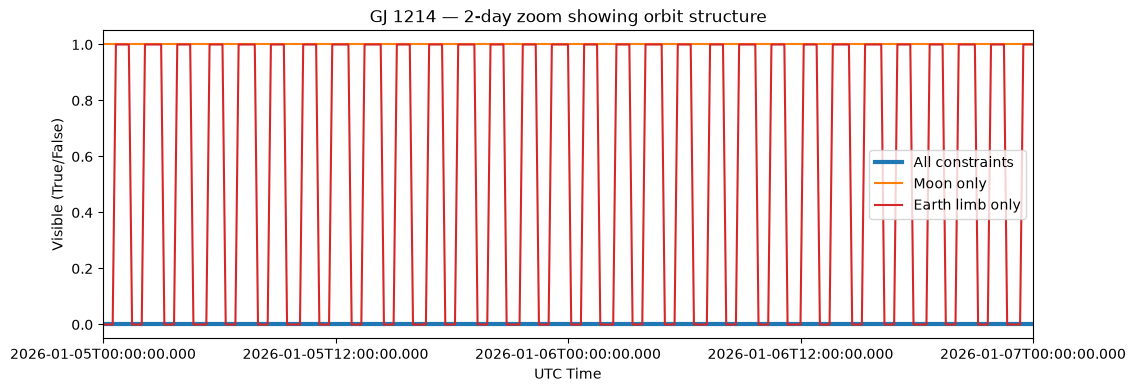

In [12]:
# Zoomed to 2 days: orbit-by-orbit Earth limb occultations are visible
with time_support():
    plt.figure(figsize=[12, 4])
    plt.plot(times.utc, targ_vis, color="C0", label="All constraints", lw=3, zorder=0)
    plt.plot(times.utc, moon_vis, label="Moon only", color="C1")
    plt.plot(times.utc, earthlimb_vis, label="Earth limb only", color="C3")
    plt.xlim(times.utc.min(), times.utc.min() + 2 * u.d)
    plt.xlabel("UTC Time")
    plt.ylabel("Visible (True/False)")
    plt.title("GJ 1214 — 2-day zoom showing orbit structure")
    plt.legend()

## 6. Custom constraints

You can override any default keep-out angle by passing keyword arguments to the `Visibility` constructor.
Here we tighten the Moon and add Jupiter and Mars constraints:

In [13]:
# Override all boresight constraints for a tighter configuration
vis_custom = Visibility(
    line1, line2,
    moon_min=20 * u.deg,
    earthlimb_min=10 * u.deg,
    sun_min=90 * u.deg,
    jupiter_min=5 * u.deg,
    mars_min=5 * u.deg,
)
print(vis_custom)
print()
print(vis_custom.summary(target_coord, times[0]))

<Visibility: SAT67395 [moon≥20 deg, sun≥90 deg, limb=dynamic, mars≥5 deg, jupiter≥5 deg, st_sun≥50 deg, st_moon≥20 deg, st_limb≥30 deg, st_req=1]>

Visibility Summary
Target: 17h15m19.4s +04d57m38.4s
Time:   2026-01-05 00:00:00.000
Sat:    67395
Moon       ✓ PASS (req:   20.0 deg, actual:  123.7 deg)
Sun        ✗ FAIL (req:   90.0 deg, actual:   38.0 deg)
Earthlimb  ✗ FAIL (req:   44.0 deg [illum 74.9°], actual:   11.3 deg)
Mars       ✓ PASS (req:    5.0 deg, actual:   39.4 deg)
Jupiter    ✓ PASS (req:    5.0 deg, actual:  137.6 deg)
------------------------------------------------------------
Star Tracker Constraints (need ≥1 tracker passing):
  ST1       ✗ FAIL
    sun:✓ req:  50.0 deg act: 124.8 deg
    moon:✓ req:  20.0 deg act:  60.9 deg
    limb:✗ req:  30.0 deg act: -41.9 deg
  ST2       ✗ FAIL
    sun:✓ req:  50.0 deg act: 124.8 deg
    moon:✓ req:  20.0 deg act:  35.5 deg
    limb:✗ req:  30.0 deg act:  26.1 deg
  Result   ✗ FAIL
Overall: ✗ NOT VISIBLE


**Note:** Changing constraints creates a new `Visibility` instance — it does not modify results already computed with the previous instance. The `vis` variable used in later cells is intentionally left unchanged so the rest of the notebook remains consistent.

## 7. Daily duty-cycle averages

Minute-by-minute visibility is noisy because the satellite enters and exits the Earth's shadow every orbit (~97 min). A more useful metric for mission planning is the **daily duty cycle** — the fraction of each day the target is visible.

The cell below bins the 10-minute boolean results into 24-hour windows (144 samples at 10-min cadence = 1 day).

In [14]:
# let's calculate the average visibility over a given day

data_numeric = targ_vis.astype(int)

# Define the window size
window_size = 144

# Calculate the running average in steps of the window size
num_windows = len(data_numeric) // window_size
running_average = [
    np.mean(data_numeric[i * window_size : (i + 1) * window_size])
    for i in range(num_windows)
]

running_average = np.array(running_average)

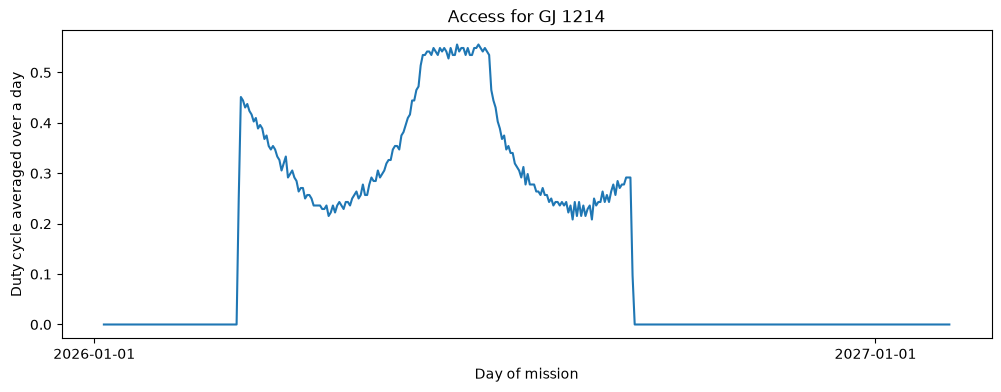

In [15]:
with time_support():
    tms = tstart + TimeDelta(np.arange(0.5, (tstop - tstart).jd, 1) * u.day)

    plt.figure(figsize=[12, 4])
    plt.plot(tms, running_average)
    plt.xlabel("Day of mission")
    plt.ylabel("Duty cycle averaged over a day")
    plt.title("Access for GJ 1214")

### 8. Convenience function: `analyze_yearly_visibility`

`analyze_yearly_visibility()` wraps the full workflow — creates a `Visibility` instance, runs the simulation, finds continuous observation windows, and returns a results dict. `plot_yearly_visibility()` renders it as a multi-panel figure.

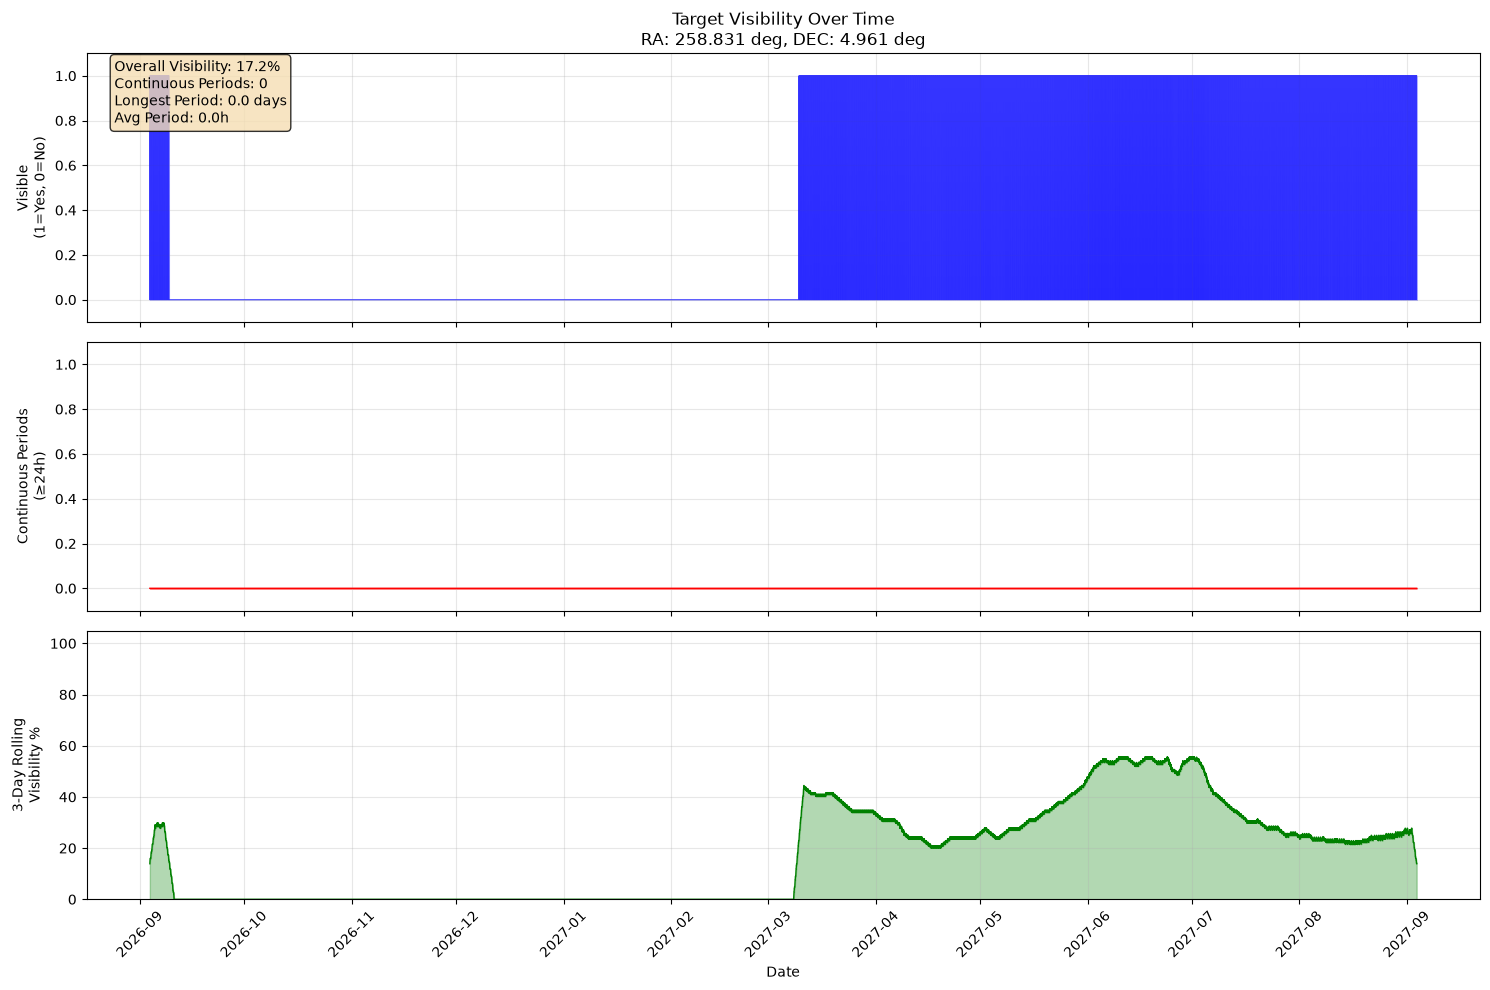

In [16]:
plot_yearly_visibility(analyze_yearly_visibility(line1, line2, target_coord, time_resolution_hours=0.5));

## 9. Multi-target comparison

Finally, we compute visibility for the full Pandora target list and visualise it as a heatmap (duty cycle per day per target) and a Mollweide sky map.

In [17]:
targets = [
    ["WASP-69", "b", 315.026, -5.09486],
    ["WASP-107", "b", 188.386, -10.1462],
    ["HIP 65 A", "b", 0.185606, -54.8308],
    ["TOI-3884", "b", 181.572, 12.507],
    ["GJ 1214", "b", 258.831, 4.96068],
    ["WASP-177", "b", 334.797, -1.83443],
    ["WASP-80", "b", 303.167, -2.14444],
    ["WASP-52", "b", 348.495, 8.76108],
    ["TOI-942", "b", 76.6496, -20.2456],
    ["K2-198", "b", 198.844, -6.46499],
    ["L 98-59", "d", 124.533, -68.3145],
    ["TOI-2427", "b", 52.2917, -31.3629],
    ["TOI-1685", "b", 68.594, 43.037],
    ["TOI-836", "b", 225.08, -24.4542],
    ["TOI-1416", "b", 216.923, 41.953],
    ["HD 3167", "b", 8.74015, 4.38072],
    ["TOI-776", "b", 178.578, -37.5534],
    ["GJ 9827", "b", 351.772, -1.28534],
    ["TOI-244", "b", 10.5698, -36.718],
    ["LTT 1445 A", "c", 45.4625, -16.5945],
]
target_df = pd.DataFrame(targets, columns=["star", "planet", "ra", "dec"])

In [18]:
# let's go through a list of targets and create a visibility for each of them

tv = {}

for i, t in target_df.iterrows():
    target_coord = SkyCoord(t.ra, t.dec, frame="icrs", unit="deg")
    targ_vis = vis.get_visibility(target_coord, times)["visible"]

    data_numeric = targ_vis.astype(int)
    # Define the window size
    window_size = 144

    # Calculate the running average in steps of the window size
    num_windows = len(data_numeric) // window_size
    running_average = [
        np.mean(data_numeric[i * window_size : (i + 1) * window_size])
        for i in range(num_windows)
    ]

    running_average = np.array(running_average)

    tv[t.star] = running_average

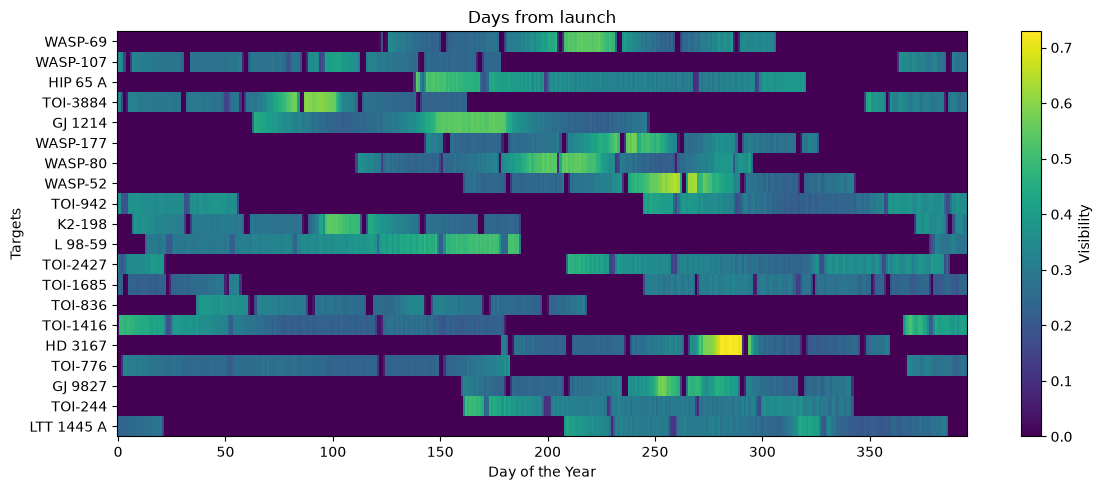

In [19]:
targets = list(tv.keys())
days = np.arange(1, 396 + 1)
visibility_matrix = np.array([tv[target] for target in targets])

fig, ax = plt.subplots(figsize=(12, 5))
cax = ax.imshow(
    visibility_matrix, aspect="auto", cmap="viridis", interpolation="nearest"
)

ax.set_yticks(np.arange(len(targets)))
ax.set_yticklabels(targets)
ax.set_xlabel("Day of the Year")
ax.set_ylabel("Targets")
plt.colorbar(cax, label="Visibility")
plt.title("Days from launch")
plt.tight_layout()
# plt.savefig("pandora-target-visibility.png", dpi=300)

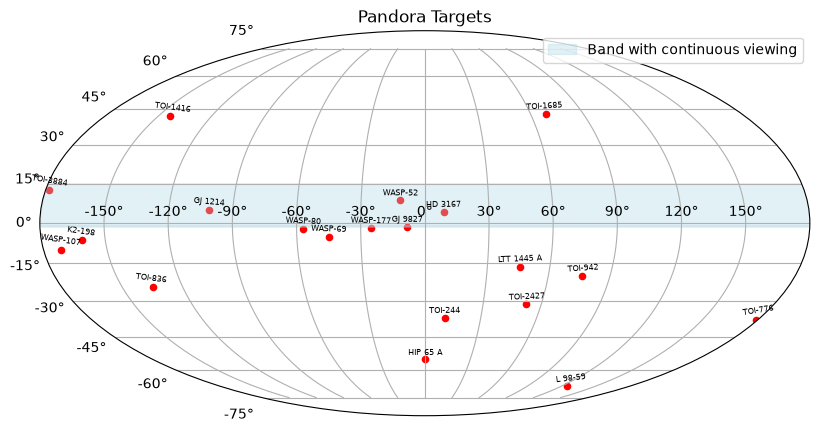

In [20]:
# Targets across the sky in a Mollweide projection
label_offset = np.radians(1)
# Convert RA to radians, wrap to [-180, 180] for Mollweide
ra_rad = np.radians(np.remainder(target_df.ra + 180, 360) - 180)
dec_rad = np.radians(target_df.dec)

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection="mollweide")
ax.scatter(ra_rad, dec_rad, s=20, color='red')

# Add band: fill between curves at Dec = 7 ± 8 degrees
# Targets in this region can be observed continuously for 30 days
dec_center = 7
dec_width = 8
ymin = np.radians(dec_center - dec_width)
ymax = np.radians(dec_center + dec_width)

# For fill_between to work, we need x values across the whole RA range
x = np.linspace(-np.pi, np.pi, 1000)
ax.fill_between(x, ymin, ymax, color='lightblue', alpha=0.35, label='Band with continuous viewing')

for ra, dec, name in zip(ra_rad, dec_rad, target_df.star):
    angle = np.degrees(ra)
    ax.text(ra, dec + label_offset, name, fontsize=6,
            rotation=angle / 20, ha='center', va='bottom', color='black')

ax.grid(True)
ax.set_title("Pandora Targets")
ax.legend()